In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
import joblib

sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
from src.data_preprocessing import clean_data, get_preprocessing_pipeline, add_features

In [3]:
df = pd.read_csv('../data/raw_data.csv')
df = clean_data(df)

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

kfold = StratifiedKFold(shuffle=True, random_state=67)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)

In [5]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in X.columns if col not in num_features]

In [6]:
pipeline = Pipeline(steps=[
    ('preprocessing', get_preprocessing_pipeline(num_features, cat_features)),
    ('model', LogisticRegression(class_weight='balanced'))
])

In [7]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_valid)

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1031
           1       0.50      0.81      0.62       371

    accuracy                           0.74      1402
   macro avg       0.71      0.76      0.71      1402
weighted avg       0.80      0.74      0.75      1402



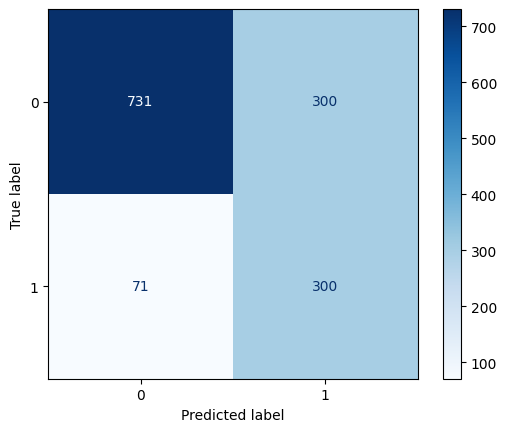

In [8]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_valid, y_valid, cmap='Blues')

plt.show()

I experimented with feature engineering (tenure binning, service counting), but since I'm using a linear Baseline (Logistic Regression), these features introduced multicollinearity and slightly decreased performance. I decided to stick with the original cleaned features for the Baseline to keep the model simple and interpretable.

In [9]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

coefficients = pipeline.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'weight': coefficients
})

feature_importance['abs_weight'] = feature_importance['weight'].abs()
feature_importance = feature_importance.sort_values(by='abs_weight', ascending=False)

print(feature_importance.head(15))

                                feature    weight  abs_weight
15               num__Contract_Two year -1.331621    1.331621
20                          cat__tenure -1.272849    1.272849
7               num__InternetService_No -0.703659    0.703659
4                 num__PhoneService_Yes -0.637024    0.637024
14               num__Contract_One year -0.633427    0.633427
6      num__InternetService_Fiber optic  0.585281    0.585281
22                    cat__TotalCharges  0.543450    0.543450
11                 num__TechSupport_Yes -0.441341    0.441341
8               num__OnlineSecurity_Yes -0.421352    0.421352
18  num__PaymentMethod_Electronic check  0.383705    0.383705
16            num__PaperlessBilling_Yes  0.312499    0.312499
1                num__SeniorCitizen_Yes  0.265818    0.265818
12                 num__StreamingTV_Yes  0.183093    0.183093
5                num__MultipleLines_Yes  0.180874    0.180874
21                  cat__MonthlyCharges  0.178633    0.178633


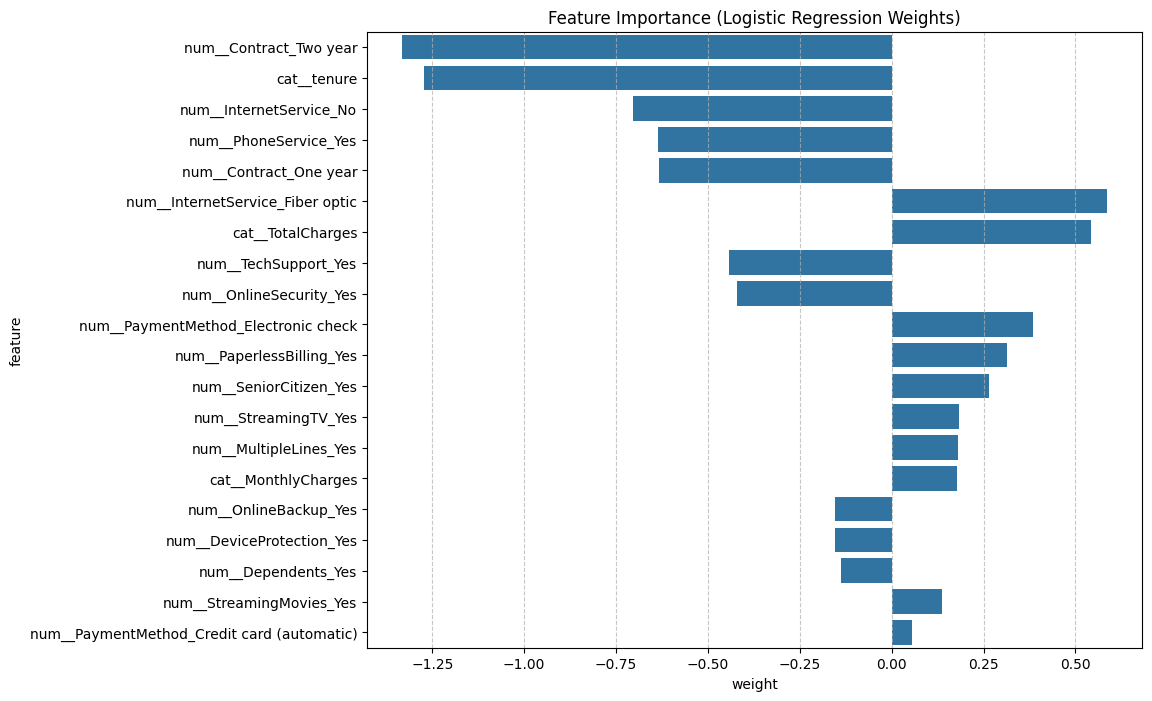

In [10]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(20), x='weight', y='feature')
plt.title('Feature Importance (Logistic Regression Weights)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [11]:
from sklearn.metrics import precision_recall_curve

y_probs = pipeline.predict_proba(X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_valid, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best Threshold: {best_threshold}")

y_pred_new = (y_probs >= best_threshold).astype(int)
print(classification_report(y_valid, y_pred_new))

Best Threshold: 0.5642979626539277
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1031
           1       0.53      0.76      0.62       371

    accuracy                           0.76      1402
   macro avg       0.71      0.76      0.72      1402
weighted avg       0.80      0.76      0.77      1402



In [12]:
from sklearn.metrics import roc_auc_score

y_probs = pipeline.predict_proba(X_valid)[:, 1]
auc_val = roc_auc_score(y_valid, y_probs)
print(f"ROC-AUC Score: {auc_val:.4f}")

ROC-AUC Score: 0.8331


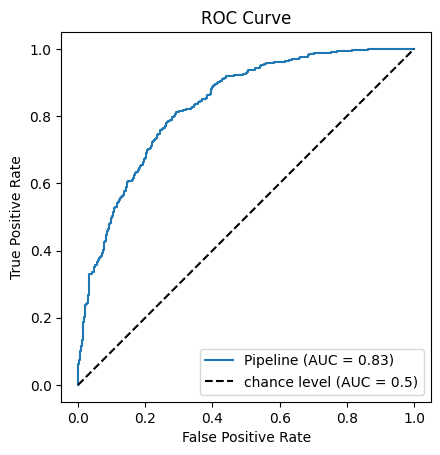

In [13]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(pipeline, X_valid, y_valid)
plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Summary of Results

After comparing Logistic Regression and CatBoost, I decided to choose **Logistic Regression** as the final model.

**Key findings:**
*   **Model Performance:** The model achieved a **Recall of 0.81** and a **ROC-AUC of 0.83**. This indicates that the model not only identifies 81% of potential churners but also has a high overall ability to distinguish between loyal and at-risk customers regardless of the chosen threshold.
*   **Business Logic:** For a churn task, I prioritized **Recall over Precision**. It is better to find more potential churners and offer them a discount than to miss them entirely.
*   **Interpretability:** Logistic Regression clearly shows the main risk factors, such as "Fiber optic" internet and "Month-to-month" contracts, which is very useful for business strategy.

**Conclusion:** This model is a strong and simple baseline that effectively solves the problem of identifying at-risk customers.

In [14]:
pipeline.fit(X, y)

joblib.dump(pipeline, '../models/final_churn_model.joblib')

['../models/final_churn_model.joblib']